# تحلیل احساسات متون فارسی
### شبکه‌های عصبی بازگشتی (Simple RNN, GRU, LSTM) و مقایسه با ParsBERT

**دانشگاه صنعتی امیرکبیر — دانشکده ریاضی و علوم کامپیوتر**
**درس یادگیری ژرف — دکتر شاکری — بهار ۱۴۰۵**

این نوت‌بوک برای اجرا در **Google Colab** طراحی شده است (ترجیحاً با GPU: Runtime → Change runtime type → GPU).

**فهرست مطالب:**
1. تنظیمات اولیه و نصب پیش‌نیازها
2. بارگذاری داده
3. کاوش داده (EDA)
4. پیش‌پردازش داده
5. تقسیم‌بندی طبقه‌بندی‌شده (Train/Val/Test)
6. نمایش متن (Vocabulary, Encoding, Padding)
7. Dataset و DataLoader در PyTorch
8. معماری مدل‌ها (Simple RNN, GRU, LSTM)
9. آموزش مدل‌ها
10. ارزیابی مدل‌ها
11. تحلیل مقایسه‌ای
12. تحلیل خطا
13. Fine-tune کردن ParsBERT
14. مقایسه نهایی و جمع‌بندی


## ۱. تنظیمات اولیه و نصب پیش‌نیازها

In [1]:
# نصب پکیج‌های مورد نیاز (در کولب اغلب از پیش نصب هستند، اما برای اطمینان اجرا می‌کنیم)
!pip install -q hazm transformers datasets scikit-learn matplotlib seaborn wordcloud arabic-reshaper python-bidi


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.5 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import time
import random
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix, f1_score)

# پشتیبانی از نمایش صحیح متن فارسی در نمودارها
import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    """برای نمایش صحیح رشته فارسی روی نمودارهای matplotlib"""
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# seed برای تکرارپذیری
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


Device: cuda


## ۲. بارگذاری داده

فایل `merged_3class.csv` را در محیط کولب آپلود کنید (از پنل سمت چپ، Files، یا با استفاده از سلول زیر) و سپس اجرا کنید.

ساختار داده شامل ستون‌های زیر است:
- `text`: متن نظر
- `label`: برچسب احساسی (0=منفی، 1=خنثی، 2=مثبت)
- `source`: پلتفرم منبع (snappfood / digikala)
- `created_at`: تاریخ ثبت (در این مجموعه داده عمدتاً خالی است)


In [3]:
from google.colab import files

# اگر فایل را از قبل در Drive یا محیط کولب دارید، این سلول را نادیده بگیرید
# و مستقیماً مسیر را در سلول بعد وارد کنید.
uploaded = files.upload()  # merged_3class.csv را انتخاب کنید
DATA_PATH = list(uploaded.keys())[0] if uploaded else 'merged_3class.csv'
print('Loaded file:', DATA_PATH)


Saving merged_3class.csv to merged_3class.csv
Loaded file: merged_3class.csv


In [4]:
# در صورتی که فایل را از Google Drive می‌خوانید، این بلوک را به‌جای بلوک بالا استفاده کنید:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/path/to/merged_3class.csv'

df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head(10)


Shape: (73828, 4)


,text,label,source,created_at
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,snappfood,NaN
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,2,snappfood,NaN
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,snappfood,NaN
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,2,snappfood,NaN
4,شیرینی وانیلی فقط یک مدل بود.,2,snappfood,NaN
5,بدترین پیتزایی که تا به حال خورده بودم,0,snappfood,NaN
6,از همه لحاظ عالی ممنونم,2,snappfood,NaN
7,کیفیت غذا متوسط رو به پایین بود انگار داخل یه ...,0,snappfood,NaN
8,همه اقلام تازه و به روز وخیلی سریع بدستم رسید ...,2,snappfood,NaN
9,همه چی خوب ولی هات داگ دورش کلا سوخته بود و دا...,0,snappfood,NaN


In [5]:
LABEL_NAMES = {0: 'منفی (Negative)', 1: 'خنثی (Neutral)', 2: 'مثبت (Positive)'}
LABEL_NAMES_EN = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73828 entries, 0 to 73827
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   text        73828 non-null  object 
 1   label       73828 non-null  int64  
 2   source      73828 non-null  object 
 3   created_at  0 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


## ۳. کاوش داده (Data Exploration)

طبق دستورالعمل پروژه، موارد زیر بررسی می‌شوند:
1. تعداد کل نمونه‌ها
2. توزیع کلاس‌ها
3. توزیع منابع داده (پلتفرم‌ها)
4. میانگین طول نظرات
5. پرتکرارترین کلمات
6. نمونه‌هایی از هر کلاس احساسی


In [6]:
# ۱. تعداد کل نمونه‌ها
print(f'تعداد کل نمونه‌ها: {len(df_raw):,}')
print(f'تعداد مقادیر تکراری: {df_raw.duplicated(subset=["text"]).sum():,}')
print(f'تعداد مقادیر گمشده در متن: {df_raw["text"].isna().sum()}')
print(f'تعداد مقادیر گمشده در برچسب: {df_raw["label"].isna().sum()}')


تعداد کل نمونه‌ها: 73,828
تعداد مقادیر تکراری: 0
تعداد مقادیر گمشده در متن: 0
تعداد مقادیر گمشده در برچسب: 0


توزیع کلاس‌ها:
  Negative (label=0): 33,479 (45.35%)
   Neutral (label=1):  2,409 (3.26%)
  Positive (label=2): 37,940 (51.39%)


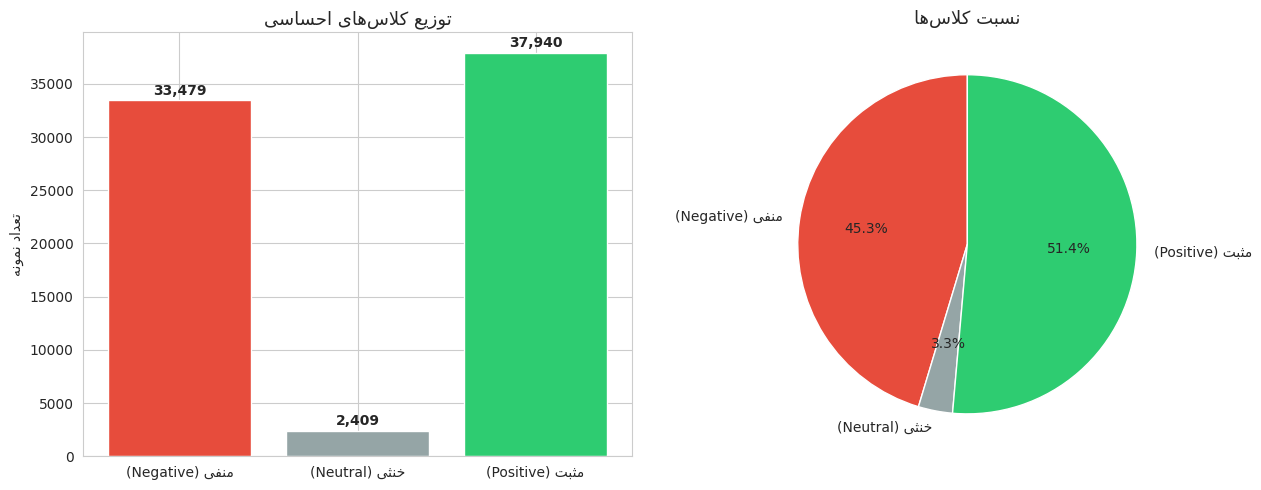


هشدار: مجموعه داده کاملاً نامتوازن است (کلاس خنثی << کلاس‌های دیگر)؛ این موضوع توجیه‌کننده استفاده از Macro F1-Score به‌عنوان معیار اصلی ارزیابی است.


In [7]:
# ۲. توزیع کلاس‌ها
class_counts = df_raw['label'].value_counts().sort_index()
class_pct = (class_counts / len(df_raw) * 100).round(2)

print('توزیع کلاس‌ها:')
for lbl, cnt in class_counts.items():
    print(f'  {LABEL_NAMES_EN[lbl]:>8} (label={lbl}): {cnt:>6,} ({class_pct[lbl]}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

axes[0].bar([fa(LABEL_NAMES[l]) for l in class_counts.index], class_counts.values, color=colors)
axes[0].set_title(fa('توزیع کلاس‌های احساسی'), fontsize=13)
axes[0].set_ylabel(fa('تعداد نمونه'))
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=[fa(LABEL_NAMES[l]) for l in class_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(fa('نسبت کلاس‌ها'), fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nهشدار: مجموعه داده کاملاً نامتوازن است (کلاس خنثی << کلاس‌های دیگر)؛'
      ' این موضوع توجیه‌کننده استفاده از Macro F1-Score به‌عنوان معیار اصلی ارزیابی است.')


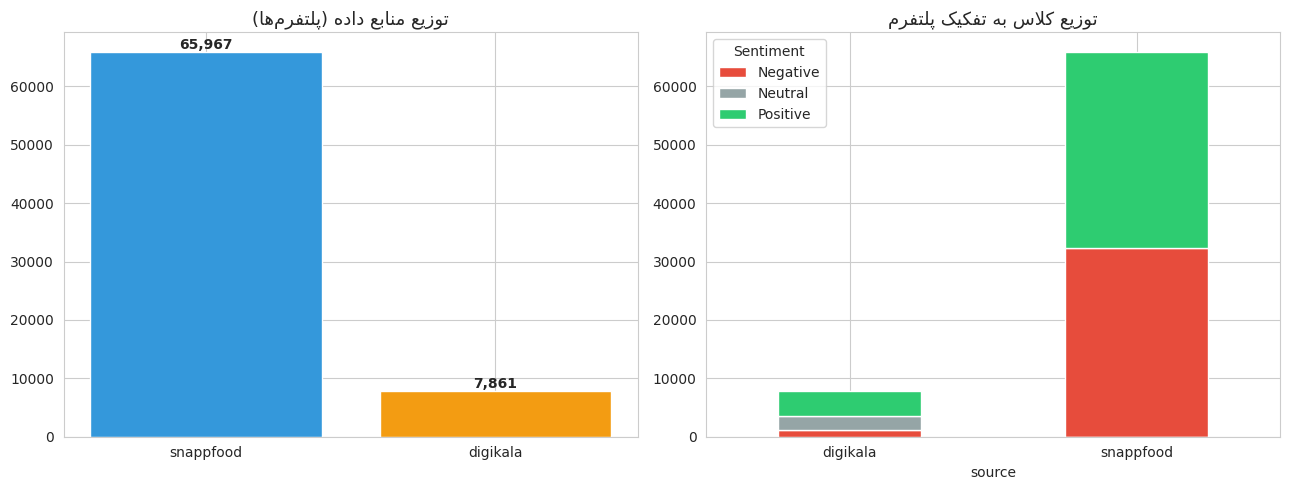

           Negative  Neutral  Positive
source                                
digikala       1183     2409      4269
snappfood     32296        0     33671


In [8]:
# ۳. توزیع منابع داده (پلتفرم‌ها)
source_counts = df_raw['source'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar([fa(s) for s in source_counts.index], source_counts.values, color=['#3498db', '#f39c12'])
axes[0].set_title(fa('توزیع منابع داده (پلتفرم‌ها)'), fontsize=13)
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# توزیع کلاس به تفکیک پلتفرم
cross = pd.crosstab(df_raw['source'], df_raw['label'])
cross.columns = [LABEL_NAMES_EN[c] for c in cross.columns]
cross.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
axes[1].set_title(fa('توزیع کلاس به تفکیک پلتفرم'), fontsize=13)
axes[1].set_xticklabels([fa(s) for s in cross.index], rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(cross)


آمار طول نظرات (کاراکتر):
count    73828.000000
mean        79.030436
std         53.448945
min          8.000000
25%         39.000000
50%         65.000000
75%        107.000000
max       1530.000000
Name: char_len, dtype: float64

آمار طول نظرات (کلمه):
count    73828.000000
mean        16.801755
std         11.270588
min          2.000000
25%          8.000000
50%         14.000000
75%         23.000000
max        331.000000
Name: word_len, dtype: float64


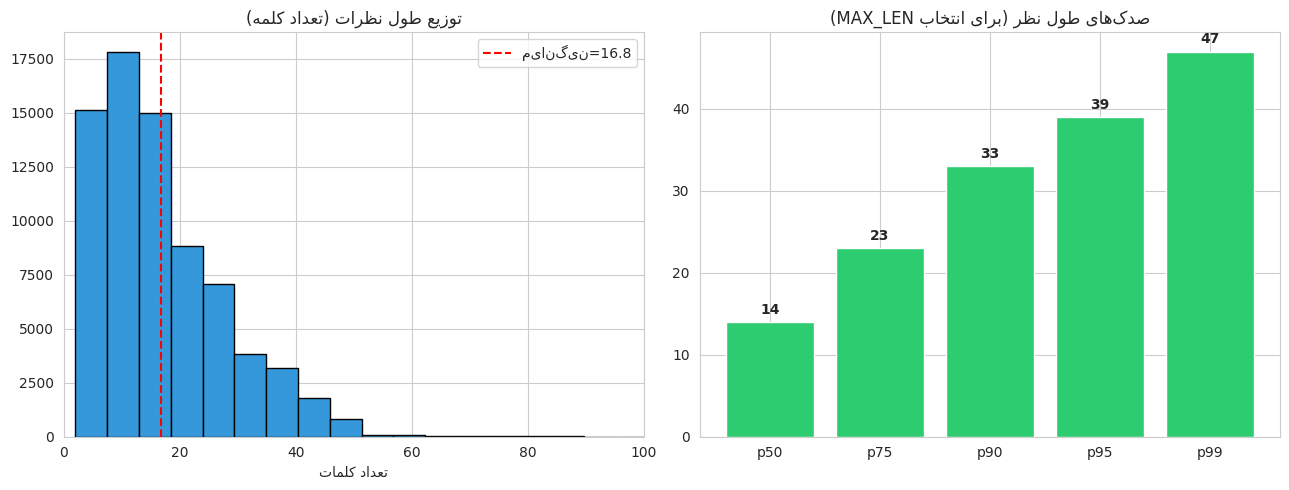


صدک ۹۵ ام طول (کلمه): 39
این مقدار به‌عنوان مبنای انتخاب MAX_LEN در بخش نمایش متن استفاده خواهد شد.


In [9]:
# ۴. میانگین طول نظرات (بر حسب تعداد کاراکتر و تعداد کلمه)
df_raw['char_len'] = df_raw['text'].astype(str).apply(len)
df_raw['word_len'] = df_raw['text'].astype(str).apply(lambda t: len(t.split()))

print('آمار طول نظرات (کاراکتر):')
print(df_raw['char_len'].describe())
print('\nآمار طول نظرات (کلمه):')
print(df_raw['word_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df_raw['word_len'], bins=60, color='#3498db', edgecolor='black')
axes[0].axvline(df_raw['word_len'].mean(), color='red', linestyle='--',
                 label=f'میانگین={df_raw["word_len"].mean():.1f}')
axes[0].set_xlim(0, 100)
axes[0].set_title(fa('توزیع طول نظرات (تعداد کلمه)'))
axes[0].set_xlabel(fa('تعداد کلمات'))
axes[0].legend()

# نمودار صدک‌ها برای انتخاب طول بهینه دنباله
percentiles = [50, 75, 90, 95, 99]
p_values = np.percentile(df_raw['word_len'], percentiles)
axes[1].bar([f'p{p}' for p in percentiles], p_values, color='#2ecc71')
axes[1].set_title(fa('صدک‌های طول نظر (برای انتخاب MAX_LEN)'))
for i, v in enumerate(p_values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nصدک ۹۵ ام طول (کلمه): {np.percentile(df_raw["word_len"], 95):.0f}')
print('این مقدار به‌عنوان مبنای انتخاب MAX_LEN در بخش نمایش متن استفاده خواهد شد.')


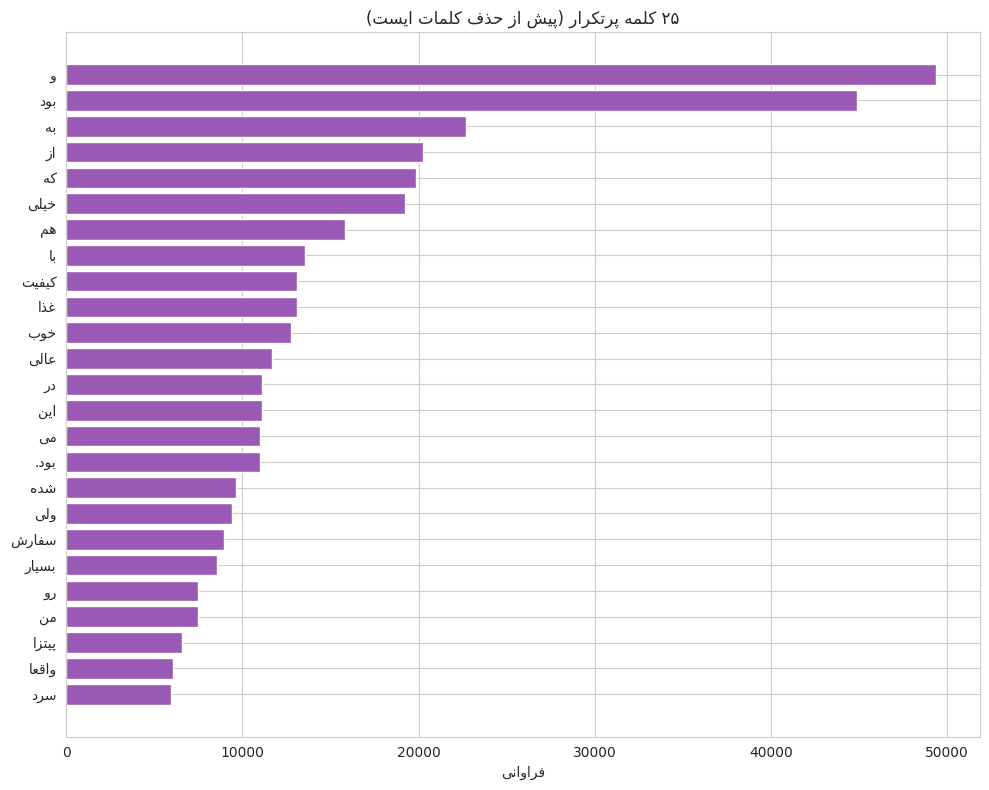

نکته: در این مرحله کلمات ایست (و، به، از، ...) هنوز حذف نشده‌اند.


In [10]:
# ۵. پرتکرارترین کلمات (پیش از پیش‌پردازش کامل، صرفاً برای کاوش اولیه)
all_words = ' '.join(df_raw['text'].astype(str).tolist()).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(25)

plt.figure(figsize=(10, 8))
words_fa = [fa(w) for w, _ in top_words][::-1]
counts_w = [c for _, c in top_words][::-1]
plt.barh(words_fa, counts_w, color='#9b59b6')
plt.title(fa('۲۵ کلمهٔ پرتکرار (پیش از حذف کلمات ایست)'))
plt.xlabel(fa('فراوانی'))
plt.tight_layout()
plt.savefig('top_words_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print('نکته: در این مرحله کلمات ایست (و، به، از، ...) هنوز حذف نشده‌اند.')


In [11]:
# ۶. نمونه‌هایی از هر کلاس احساسی
for lbl in sorted(df_raw['label'].unique()):
    print(f'--- {LABEL_NAMES_EN[lbl]} (label={lbl}) ---')
    samples = df_raw[df_raw['label'] == lbl]['text'].sample(3, random_state=SEED).tolist()
    for s in samples:
        print(' •', s)
    print()


--- Negative (label=0) ---
 • متاسفانه بر خلاف انتظار همبرگر خام و قرمز بود
 • فکر کنم خامش مال یه هفته پیش بود. به شدت کهنه. تو دهن می ماسید.
 • اگه عکس شیرینی هم گذاشته بشه بهتره خیلی شبیه اکلر بود

--- Neutral (label=1) ---
 • کارتریج این چندکاره دارای 4 کارتریج می باشد.
 • همچنین مجهز به نمایشگر 3 اینچی لمسی با رزولوشن 230,000 پیکسل است و بیشتر کنترل های دوربین را می بایست از طریق همین نمایشگر بر عهده بگیرید.
 • در سمت چپ گوشی هیچ شیاری قرار ندارد، اما در سمت مقابل یعنی سمت راست آن، شکاف میکرو سیم کارت، کلید کنترل صدا کلید شاتر دوربین تعبیه شده اند.

--- Positive (label=2) ---
 • کیفیت غذاو بسته بندی غذا خوب است
 • مرسی خیلب راضی بودم
 • عالی بود، فقط کمی شل بود، اونطوری یخ نبود که جیگر آدم حال بیاد، ولی در کل عالی



## ۴. پیش‌پردازش داده (Data Preprocessing)

مراحل زیر روی متن فارسی اعمال می‌شوند و هرکدام توجیه شده‌اند:

| مرحله | توجیه |
|---|---|
| حذف نمونه‌های تکراری | جلوگیری از نشت داده (data leakage) بین train/val/test و جلوگیری از تورم مصنوعی یک کلاس |
| مدیریت مقادیر گمشده | حذف رکوردهایی که متن یا برچسب ندارند |
| یکسان‌سازی کاراکترهای عربی/فارسی | مثلاً «ي» عربی به «ی» فارسی، «ك» عربی به «ک» فارسی — این تفاوت‌ها باعث تکه‌تکه‌شدن واژگان می‌شوند |
| نرمال‌سازی متن (فاصله مجازی/نیم‌فاصله) | یکنواخت‌سازی نویسه‌ها با استفاده از `hazm.Normalizer` |
| حذف URL | لینک‌ها اطلاعات احساسی ندارند و واژگان را بی‌جهت بزرگ می‌کنند |
| حذف علائم نگارشی و اموجی‌های نویسه‌ای غیرضروری | کاهش نویز، اما علائم تکرارشونده (مثل !!!) می‌توانند نشانه شدت احساس باشند، بنابراین قبل از حذف کامل به یک علامت تقلیل می‌یابند |
| حذف اعداد انگلیسی/فارسی مجزا (اختیاری، پیکربندی‌پذیر) | اعداد به‌تنهایی معمولاً بار احساسی ندارند |
| حذف فاصله‌های اضافی | یکنواخت‌سازی خروجی توکن‌ساز |
| توکن‌سازی | با `hazm.word_tokenize` که برای فارسی بهینه شده |
| حذف کلمات ایست (اختیاری، پیش‌فرض: غیرفعال) | در تحلیل احساسات برخی کلمات ایست (نه، اما، ولی) بار معنایی دارند؛ بنابراین به‌صورت پیش‌فرض غیرفعال نگه داشته می‌شود، ولی به‌عنوان گزینه در دسترس است |
| ریشه‌یابی/لماتیزاسیون (اختیاری، پیش‌فرض: غیرفعال) | برای مدل‌های مبتنی بر Embedding قابل‌آموزش، حفظ شکل سطحی کلمه معمولاً اطلاعات بیشتری نسبت به ریشه حفظ می‌کند؛ گزینه اختیاری در دسترس است |

توجه: از حذف کامل امتیازها/شکلک‌ها با احتیاط استفاده می‌شود چون در متون شبکه‌های اجتماعی و نظرات آنلاین، این نشانه‌ها می‌توانند بار احساسی داشته باشند؛ اینجا decision این است که آنها را حذف کنیم تا واژگان کوچک‌تر و مدل سبک‌تر شود (با توجه به محدودیت‌های معماری‌های بازگشتی ساده).


In [12]:
import hazm

normalizer = hazm.Normalizer()
tokenizer = hazm.WordTokenizer()  # نمونه‌سازی یک‌باره؛ فراخوانی مستقیم hazm.word_tokenize در حلقه بسیار کند است

# نگاشت کاراکترهای عربی به معادل فارسی (برای اطمینان بیشتر، مکمل hazm)
AR2FA = {
    'ي': 'ی', 'ك': 'ک', 'ة': 'ه', 'ۀ': 'ه',
    'إ': 'ا', 'أ': 'ا', 'آ': 'آ', 'ؤ': 'و', 'ئ': 'ی',
    '٠': '۰', '١': '۱', '٢': '۲', '٣': '۳', '٤': '۴',
    '٥': '۵', '٦': '۶', '٧': '۷', '٨': '۸', '٩': '۹',
}

URL_RE = re.compile(r'(https?://\S+|www\.\S+)')
EMAIL_RE = re.compile(r'\S+@\S+')
REPEAT_PUNCT_RE = re.compile(r'([!؟?.,،])\1{1,}')
MULTI_SPACE_RE = re.compile(r'\s+')
# نگه‌داشتن حروف فارسی، فاصله، نیم‌فاصله و علائم مهم نگارشی (! ؟ .)
KEEP_CHARS_RE = re.compile(r'[^\u0600-\u06FF\u200c\s!؟.]')


def unify_arabic_chars(text: str) -> str:
    for ar, fa_ch in AR2FA.items():
        text = text.replace(ar, fa_ch)
    return text


def clean_text(text: str,
               remove_stopwords: bool = False,
               do_lemmatize: bool = False) -> str:
    if not isinstance(text, str):
        return ''
    text = unicodedata.normalize('NFKC', text)
    text = URL_RE.sub(' ', text)
    text = EMAIL_RE.sub(' ', text)
    text = unify_arabic_chars(text)
    text = normalizer.normalize(text)
    text = REPEAT_PUNCT_RE.sub(r'\1', text)          # !!! -> !
    text = KEEP_CHARS_RE.sub(' ', text)               # حذف نویسه‌های غیرفارسی/غیرضروری
    text = MULTI_SPACE_RE.sub(' ', text).strip()

    tokens = tokenizer.tokenize(text)

    if remove_stopwords:
        stopwords = set(hazm.stopwords_list())
        tokens = [t for t in tokens if t not in stopwords]

    if do_lemmatize:
        lemmatizer = hazm.Lemmatizer()
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# تست سریع تابع پاک‌سازی
sample = df_raw['text'].iloc[0]
print('قبل:', sample)
print('بعد:', clean_text(sample))


قبل: واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
بعد: واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح


In [13]:
# اعمال پیش‌پردازش روی کل داده
df = df_raw.copy()

# حذف مقادیر گمشده
df = df.dropna(subset=['text', 'label']).reset_index(drop=True)

# حذف نمونه‌های تکراری (بر اساس متن خام)
before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f'تعداد نمونه‌های تکراری حذف‌شده: {before - len(df):,}')

# پاک‌سازی متن (بدون حذف کلمات ایست / بدون لماتیزاسیون - پیش‌فرض)
REMOVE_STOPWORDS = False
DO_LEMMATIZE = False

df['clean_text'] = df['text'].apply(
    lambda t: clean_text(t, remove_stopwords=REMOVE_STOPWORDS, do_lemmatize=DO_LEMMATIZE)
)

# حذف متن‌هایی که بعد از پاک‌سازی خالی شدند
before2 = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'تعداد نمونه‌های خالی‌شده پس از پاک‌سازی که حذف شدند: {before2 - len(df):,}')

df['label'] = df['label'].astype(int)
print('شکل نهایی داده پس از پیش‌پردازش:', df.shape)
df[['text', 'clean_text', 'label']].head(10)


تعداد نمونه‌های تکراری حذف‌شده: 0
تعداد نمونه‌های خالی‌شده پس از پاک‌سازی که حذف شدند: 199
شکل نهایی داده پس از پیش‌پردازش: (73629, 7)


,text,clean_text,label
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,2
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,قیمت این مدل اصلا با کیفیتش سازگاری نداره ، فق...,0
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,عالی بود همه چه درست و به اندازه و کیفیت خوب ،...,2
4,شیرینی وانیلی فقط یک مدل بود.,شیرینی وانیلی فقط یک مدل بود .,2
5,بدترین پیتزایی که تا به حال خورده بودم,بدترین پیتزایی که تا به حال خورده_بودم,0
6,از همه لحاظ عالی ممنونم,از همه لحاظ عالی ممنونم,2
7,کیفیت غذا متوسط رو به پایین بود انگار داخل یه ...,کیفیت غذا متوسط رو به پایین بود انگار داخل یه ...,0
8,همه اقلام تازه و به روز وخیلی سریع بدستم رسید ...,همه اقلام تازه و به‌روز وخیلی سریع بدستم رسید ...,2
9,همه چی خوب ولی هات داگ دورش کلا سوخته بود و دا...,همه چی خوب ولی هات داگ دورش کلا سوخته_بود و دا...,0


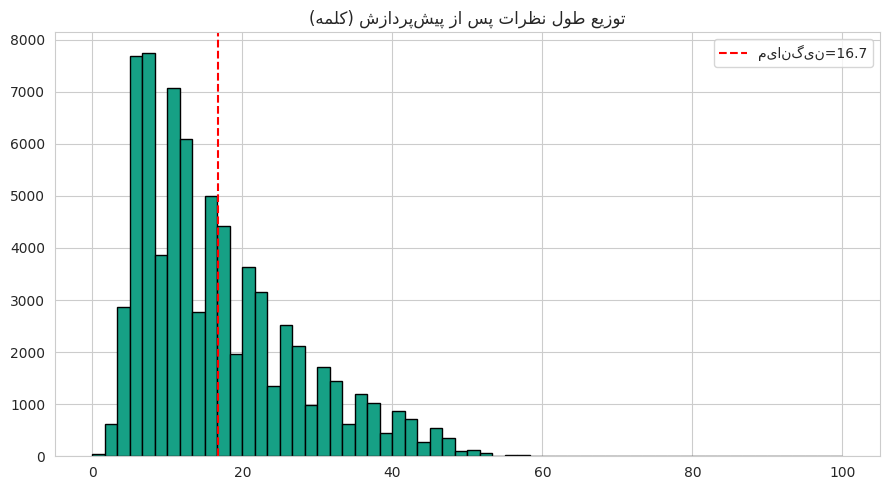

MAX_LEN انتخاب‌شده بر اساس صدک ۹۵ ام: 39


In [14]:
# مقایسه توزیع طول قبل و بعد از پیش‌پردازش
df['clean_word_len'] = df['clean_text'].apply(lambda t: len(t.split()))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['clean_word_len'], bins=60, range=(0, 100), color='#16a085', edgecolor='black')
ax.axvline(df['clean_word_len'].mean(), color='red', linestyle='--',
           label=f'میانگین={df["clean_word_len"].mean():.1f}')
ax.set_title(fa('توزیع طول نظرات پس از پیش‌پردازش (کلمه)'))
ax.legend()
plt.tight_layout()
plt.savefig('clean_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

MAX_LEN = int(np.percentile(df['clean_word_len'], 95))
MAX_LEN = max(MAX_LEN, 8)
print(f'MAX_LEN انتخاب‌شده بر اساس صدک ۹۵ ام: {MAX_LEN}')


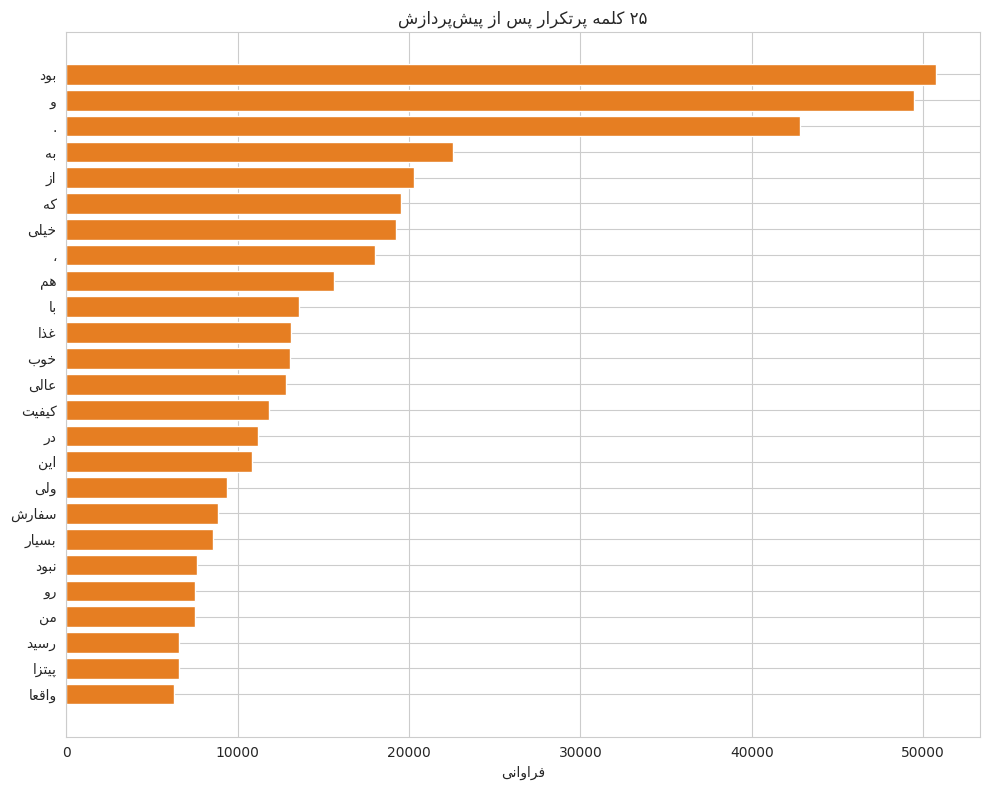

In [15]:
# پرتکرارترین کلمات پس از پیش‌پردازش
clean_words = ' '.join(df['clean_text']).split()
clean_freq = Counter(clean_words)
top_clean = clean_freq.most_common(25)

plt.figure(figsize=(10, 8))
words_fa2 = [fa(w) for w, _ in top_clean][::-1]
counts_w2 = [c for _, c in top_clean][::-1]
plt.barh(words_fa2, counts_w2, color='#e67e22')
plt.title(fa('۲۵ کلمهٔ پرتکرار پس از پیش‌پردازش'))
plt.xlabel(fa('فراوانی'))
plt.tight_layout()
plt.savefig('top_words_clean.png', dpi=150, bbox_inches='tight')
plt.show()


## ۵. تقسیم‌بندی طبقه‌بندی‌شده (Stratified Split)

داده به سه بخش train (۷۰٪)، validation (۱۵٪) و test (۱۵٪) با حفظ توزیع کلاس‌ها در هر زیرمجموعه تقسیم می‌شود.
این تقسیم‌بندی برای **همه مدل‌ها** (RNN، GRU، LSTM و ParsBERT) یکسان استفاده خواهد شد.


In [16]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = d['label'].value_counts(normalize=True).sort_index() * 100
    print(f'{name} distribution (%):', {int(k): round(v, 2) for k, v in dist.items()})


Train: 51,540  Val: 11,044  Test: 11,045
Train distribution (%): {0: 45.36, 1: 3.27, 2: 51.37}
Val distribution (%): {0: 45.36, 1: 3.27, 2: 51.37}
Test distribution (%): {0: 45.36, 1: 3.28, 2: 51.36}


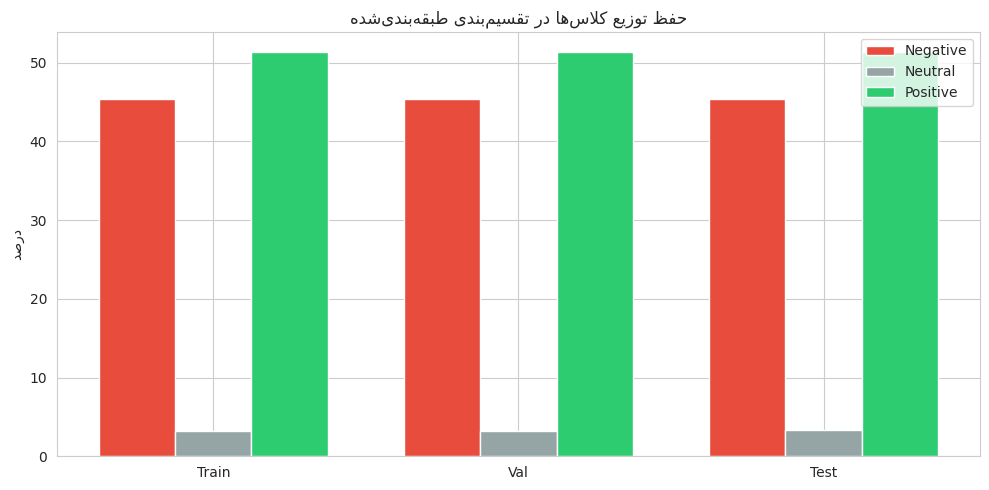

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
splits = ['Train', 'Val', 'Test']
split_dfs = [train_df, val_df, test_df]
width = 0.25
x = np.arange(3)
for i, lbl in enumerate([0, 1, 2]):
    pct = [ (d['label'] == lbl).mean() * 100 for d in split_dfs ]
    ax.bar(x + i * width, pct, width, label=LABEL_NAMES_EN[lbl], color=colors[i])
ax.set_xticks(x + width)
ax.set_xticklabels(splits)
ax.set_ylabel(fa('درصد'))
ax.set_title(fa('حفظ توزیع کلاس‌ها در تقسیم‌بندی طبقه‌بندی‌شده'))
ax.legend()
plt.tight_layout()
plt.savefig('stratified_split.png', dpi=150, bbox_inches='tight')
plt.show()


## ۶. نمایش متن (Text Representation)

طبق دستورالعمل پروژه از نمایش‌های مبتنی بر دنباله استفاده می‌شود (بدون TF-IDF / Bag-of-Words / Count Vectors):
1. توکن‌سازی (قبلاً در پیش‌پردازش انجام شد)
2. ساخت واژگان
3. رمزگذاری عددی توکن‌ها
4. لایه‌گذاری/برش دنباله‌ها (Padding/Truncation)
5. لایه جاسازی قابل‌آموزش (در داخل مدل تعریف می‌شود)

واژگان **فقط از داده train** ساخته می‌شود تا از نشت داده جلوگیری شود.


In [18]:
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
MIN_FREQ = 2  # کلماتی با فراوانی کمتر از این مقدار در داده train نادیده گرفته می‌شوند

def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.most_common():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_df['clean_text'])
VOCAB_SIZE = len(vocab)
print(f'اندازه واژگان (ساخته‌شده فقط از train، min_freq={MIN_FREQ}): {VOCAB_SIZE:,}')

idx2word = {idx: w for w, idx in vocab.items()}


اندازه واژگان (ساخته‌شده فقط از train، min_freq=2): 12,963


In [19]:
def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

# تست سریع
sample_ids = encode_text(train_df['clean_text'].iloc[0], vocab)
print('متن:', train_df['clean_text'].iloc[0])
print('رمزگذاری‌شده:', sample_ids)
print('طول:', len(sample_ids))


متن: سرد ، بدون سرویس ، سیب‌زمینی انگار از دیروز مونده . افتضاح افتضاح افتضاح
رمزگذاری‌شده: [27, 9, 140, 582, 9, 70, 189, 6, 1185, 204, 4, 143, 143, 143, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
طول: 39


## ۷. Dataset و DataLoader در PyTorch

In [20]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts.iloc[idx], self.vocab, self.max_len)
        label = int(self.labels.iloc[idx])
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


BATCH_SIZE = 64

train_ds = SentimentDataset(train_df['clean_text'], train_df['label'], vocab)
val_ds   = SentimentDataset(val_df['clean_text'],   val_df['label'],   vocab)
test_ds  = SentimentDataset(test_df['clean_text'],  test_df['label'],  vocab)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print('Batch shape:', xb.shape, yb.shape)


Batch shape: torch.Size([64, 39]) torch.Size([64])


## ۸. معماری مدل‌ها

هر سه معماری (Simple RNN، GRU، LSTM) از یک اسکلت مشترک استفاده می‌کنند تا مقایسه منصفانه باشد:

`Embedding Layer (قابل‌آموزش) → RNN/GRU/LSTM (چند لایه، دوطرفه اختیاری) → Dropout → Fully-Connected → 3 کلاس`

پارامترهای قابل تنظیم: تعداد لایه‌های بازگشتی، ابعاد پنهان، Dropout، دوطرفه‌بودن.


In [21]:
class RecurrentSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 rnn_type='lstm', num_layers=1, bidirectional=False,
                 dropout=0.3, pad_idx=0):
        super().__init__()
        self.rnn_type = rnn_type.lower()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)

        rnn_kwargs = dict(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        if self.rnn_type == 'rnn':
            self.rnn = nn.RNN(**rnn_kwargs, nonlinearity='tanh')
        elif self.rnn_type == 'gru':
            self.rnn = nn.GRU(**rnn_kwargs)
        elif self.rnn_type == 'lstm':
            self.rnn = nn.LSTM(**rnn_kwargs)
        else:
            raise ValueError(f'Unknown rnn_type: {rnn_type}')

        num_directions = 2 if bidirectional else 1
        self.fc_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * num_directions, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        mask = (x != 0)
        lengths = mask.sum(dim=1).clamp(min=1).cpu()

        emb = self.emb_dropout(self.embedding(x))            # (batch, seq_len, embed_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths, batch_first=True, enforce_sorted=False)

        if self.rnn_type == 'lstm':
            _, (hidden, _) = self.rnn(packed)
        else:
            _, hidden = self.rnn(packed)

        # hidden: (num_layers * num_directions, batch, hidden_dim)
        if self.rnn.bidirectional:
            last_fwd = hidden[-2]
            last_bwd = hidden[-1]
            final_hidden = torch.cat([last_fwd, last_bwd], dim=1)
        else:
            final_hidden = hidden[-1]

        out = self.fc_dropout(final_hidden)
        logits = self.fc(out)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [22]:
# پیکربندی مشترک برای مقایسه منصفانه بین معماری‌ها
COMMON_CONFIG = dict(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=128,
    num_classes=3,
    num_layers=1,
    bidirectional=False,
    dropout=0.3,
    pad_idx=0,
)

model_rnn  = RecurrentSentimentClassifier(rnn_type='rnn',  **COMMON_CONFIG).to(device)
model_gru  = RecurrentSentimentClassifier(rnn_type='gru',  **COMMON_CONFIG).to(device)
model_lstm = RecurrentSentimentClassifier(rnn_type='lstm', **COMMON_CONFIG).to(device)

for name, m in [('Simple RNN', model_rnn), ('GRU', model_gru), ('LSTM', model_lstm)]:
    print(f'{name}: {count_parameters(m):,} trainable parameters')
    print(m)
    print('-' * 80)


Simple RNN: 1,692,675 trainable parameters
RecurrentSentimentClassifier(
  (embedding): Embedding(12963, 128, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (rnn): RNN(128, 128, batch_first=True)
  (fc_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)
--------------------------------------------------------------------------------
GRU: 1,758,723 trainable parameters
RecurrentSentimentClassifier(
  (embedding): Embedding(12963, 128, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (rnn): GRU(128, 128, batch_first=True)
  (fc_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)
--------------------------------------------------------------------------------
LSTM: 1,791,747 trainable parameters
RecurrentSentimentClassifier(
  (embedding): Embedding(12963, 128, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (rnn): LSTM(128, 128, batch_first=Tru

## ۹. آموزش مدل‌ها (Training Procedure)

از موارد زیر استفاده می‌شود:
- بهینه‌ساز Adam
- تابع خطای Cross-Entropy (با وزن‌دهی کلاس برای مقابله با عدم توازن)
- Early Stopping بر اساس Macro F1 روی داده اعتبارسنجی
- ذخیره بهترین چک‌پوینت هر مدل


In [23]:
# محاسبه وزن کلاس‌ها برای مقابله با عدم توازن (inverse frequency)
class_counts_train = train_df['label'].value_counts().sort_index()
class_weights = (1.0 / class_counts_train)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)
print('وزن کلاس‌ها:', class_weights_tensor)


وزن کلاس‌ها: tensor([0.1905, 2.6413, 0.1682], device='cuda:0')


In [24]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    return {
        'loss': avg_loss, 'accuracy': acc,
        'precision': precision, 'recall': recall, 'f1_macro': f1,
        'preds': all_preds, 'labels': all_labels,
    }


def train_model(model, train_loader, val_loader, model_name,
                 epochs=15, lr=1e-3, patience=4, weight_decay=1e-5,
                 checkpoint_dir='checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, f'{model_name}_best.pt')

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'val_f1_macro': []}

    best_f1 = -1.0
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_metrics = evaluate_model(model, val_loader, criterion)
        scheduler.step(val_metrics['f1_macro'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1_macro'].append(val_metrics['f1_macro'])

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} "
              f"val_f1_macro={val_metrics['f1_macro']:.4f}")

        if val_metrics['f1_macro'] > best_f1:
            best_f1 = val_metrics['f1_macro']
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping در epoch {epoch} (بدون بهبود به مدت {patience} epoch)')
                break

    total_time = time.time() - start_time
    model.load_state_dict(torch.load(ckpt_path))
    print(f'بهترین val Macro-F1: {best_f1:.4f} | زمان آموزش: {total_time:.1f} ثانیه')
    return model, history, total_time


In [25]:
EPOCHS = 15
PATIENCE = 4
LR = 1e-3

model_rnn, history_rnn, time_rnn = train_model(
    model_rnn, train_loader, val_loader, model_name='simple_rnn',
    epochs=EPOCHS, lr=LR, patience=PATIENCE)


[simple_rnn] Epoch 01/15 | train_loss=0.7012 train_acc=0.6514 | val_loss=0.5913 val_acc=0.7323 val_f1_macro=0.6479
[simple_rnn] Epoch 02/15 | train_loss=0.5549 train_acc=0.7444 | val_loss=0.4897 val_acc=0.7833 val_f1_macro=0.6940
[simple_rnn] Epoch 03/15 | train_loss=0.4984 train_acc=0.7702 | val_loss=0.4987 val_acc=0.7806 val_f1_macro=0.6910
[simple_rnn] Epoch 04/15 | train_loss=0.4689 train_acc=0.7809 | val_loss=0.4876 val_acc=0.7898 val_f1_macro=0.7003
[simple_rnn] Epoch 05/15 | train_loss=0.4528 train_acc=0.7905 | val_loss=0.4619 val_acc=0.8047 val_f1_macro=0.7193
[simple_rnn] Epoch 06/15 | train_loss=0.4320 train_acc=0.7956 | val_loss=0.4961 val_acc=0.8154 val_f1_macro=0.7344
[simple_rnn] Epoch 07/15 | train_loss=0.4120 train_acc=0.8047 | val_loss=0.5543 val_acc=0.7715 val_f1_macro=0.6915
[simple_rnn] Epoch 08/15 | train_loss=0.4078 train_acc=0.8071 | val_loss=0.5115 val_acc=0.7989 val_f1_macro=0.7127
[simple_rnn] Epoch 09/15 | train_loss=0.3886 train_acc=0.8120 | val_loss=0.4996 

In [26]:
model_gru, history_gru, time_gru = train_model(
    model_gru, train_loader, val_loader, model_name='gru',
    epochs=EPOCHS, lr=LR, patience=PATIENCE)


[gru] Epoch 01/15 | train_loss=0.5730 train_acc=0.7131 | val_loss=0.4753 val_acc=0.7889 val_f1_macro=0.6935
[gru] Epoch 02/15 | train_loss=0.4264 train_acc=0.7930 | val_loss=0.4281 val_acc=0.8001 val_f1_macro=0.7075
[gru] Epoch 03/15 | train_loss=0.3823 train_acc=0.8126 | val_loss=0.4210 val_acc=0.8194 val_f1_macro=0.7370
[gru] Epoch 04/15 | train_loss=0.3559 train_acc=0.8234 | val_loss=0.4170 val_acc=0.8214 val_f1_macro=0.7389
[gru] Epoch 05/15 | train_loss=0.3315 train_acc=0.8346 | val_loss=0.4114 val_acc=0.8192 val_f1_macro=0.7349
[gru] Epoch 06/15 | train_loss=0.3136 train_acc=0.8425 | val_loss=0.4578 val_acc=0.8293 val_f1_macro=0.7503
[gru] Epoch 07/15 | train_loss=0.2948 train_acc=0.8515 | val_loss=0.4833 val_acc=0.8320 val_f1_macro=0.7566
[gru] Epoch 08/15 | train_loss=0.2793 train_acc=0.8562 | val_loss=0.4714 val_acc=0.8310 val_f1_macro=0.7539
[gru] Epoch 09/15 | train_loss=0.2660 train_acc=0.8633 | val_loss=0.5262 val_acc=0.8358 val_f1_macro=0.7625
[gru] Epoch 10/15 | train_lo

In [27]:
model_lstm, history_lstm, time_lstm = train_model(
    model_lstm, train_loader, val_loader, model_name='lstm',
    epochs=EPOCHS, lr=LR, patience=PATIENCE)


[lstm] Epoch 01/15 | train_loss=0.5811 train_acc=0.7089 | val_loss=0.4748 val_acc=0.7728 val_f1_macro=0.6750
[lstm] Epoch 02/15 | train_loss=0.4414 train_acc=0.7829 | val_loss=0.4279 val_acc=0.8036 val_f1_macro=0.7152
[lstm] Epoch 03/15 | train_loss=0.3890 train_acc=0.8089 | val_loss=0.4269 val_acc=0.8062 val_f1_macro=0.7169
[lstm] Epoch 04/15 | train_loss=0.3562 train_acc=0.8209 | val_loss=0.4111 val_acc=0.8189 val_f1_macro=0.7356
[lstm] Epoch 05/15 | train_loss=0.3331 train_acc=0.8338 | val_loss=0.4291 val_acc=0.8290 val_f1_macro=0.7529
[lstm] Epoch 06/15 | train_loss=0.3145 train_acc=0.8408 | val_loss=0.4256 val_acc=0.8278 val_f1_macro=0.7475
[lstm] Epoch 07/15 | train_loss=0.2941 train_acc=0.8505 | val_loss=0.4387 val_acc=0.8281 val_f1_macro=0.7516
[lstm] Epoch 08/15 | train_loss=0.2806 train_acc=0.8567 | val_loss=0.5159 val_acc=0.8325 val_f1_macro=0.7603
[lstm] Epoch 09/15 | train_loss=0.2653 train_acc=0.8622 | val_loss=0.4894 val_acc=0.8340 val_f1_macro=0.7599
[lstm] Epoch 10/15 

### منحنی‌های آموزش (Loss / Accuracy / F1)

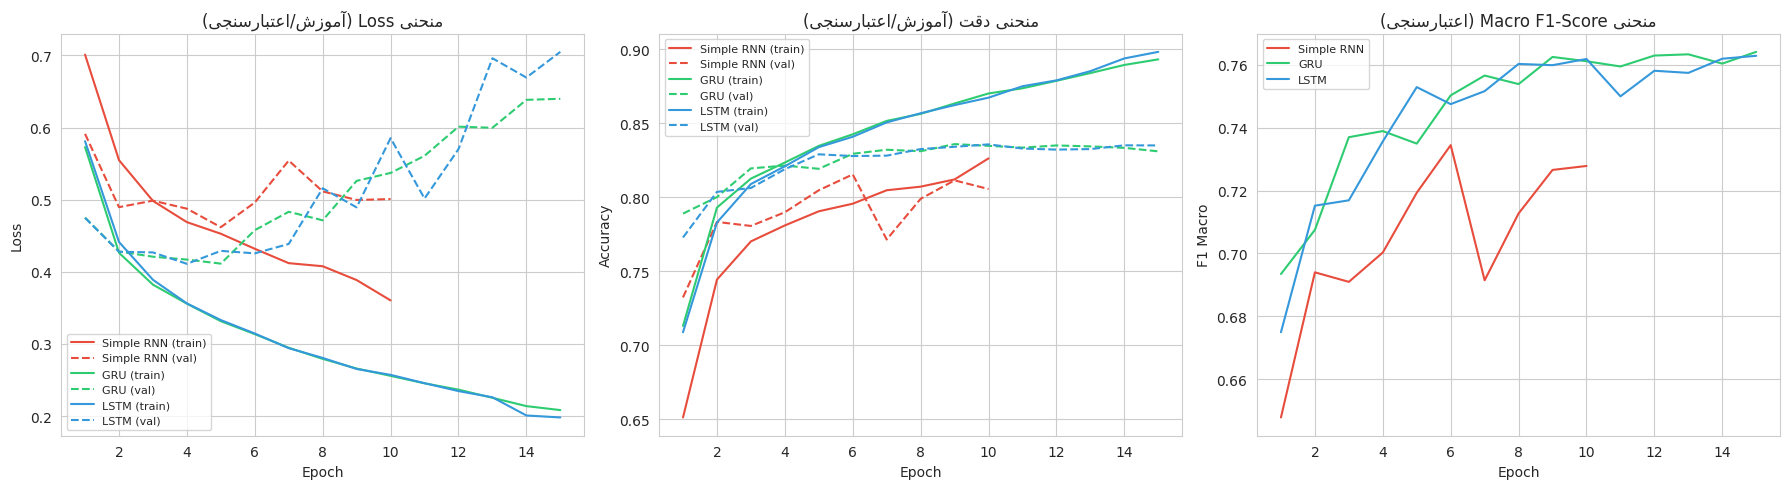

In [28]:
def plot_training_curves(histories, names):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors_line = ['#e74c3c', '#2ecc71', '#3498db']

    for h, name, c in zip(histories, names, colors_line):
        epochs_range = range(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs_range, h['train_loss'], color=c, linestyle='-', label=f'{name} (train)')
        axes[0].plot(epochs_range, h['val_loss'], color=c, linestyle='--', label=f'{name} (val)')

    axes[0].set_title(fa('منحنی Loss (آموزش/اعتبارسنجی)'))
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=8)

    for h, name, c in zip(histories, names, colors_line):
        epochs_range = range(1, len(h['train_acc']) + 1)
        axes[1].plot(epochs_range, h['train_acc'], color=c, linestyle='-', label=f'{name} (train)')
        axes[1].plot(epochs_range, h['val_acc'], color=c, linestyle='--', label=f'{name} (val)')

    axes[1].set_title(fa('منحنی دقت (آموزش/اعتبارسنجی)'))
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=8)

    for h, name, c in zip(histories, names, colors_line):
        epochs_range = range(1, len(h['val_f1_macro']) + 1)
        axes[2].plot(epochs_range, h['val_f1_macro'], color=c, label=name)

    axes[2].set_title(fa('منحنی Macro F1-Score (اعتبارسنجی)'))
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1 Macro'); axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(
    [history_rnn, history_gru, history_lstm],
    ['Simple RNN', 'GRU', 'LSTM']
)


## ۱۰. ارزیابی مدل‌ها (Evaluation)

معیارهای ارزیابی: Accuracy، Precision، Recall، **Macro F1-Score (معیار اصلی)**، Confusion Matrix و Classification Report — روی داده **test**.


In [29]:
criterion_eval = nn.CrossEntropyLoss(weight=class_weights_tensor)

results = {}
for name, model in [('Simple RNN', model_rnn), ('GRU', model_gru), ('LSTM', model_lstm)]:
    metrics = evaluate_model(model, test_loader, criterion_eval)
    results[name] = metrics
    print(f'=== {name} — Test Set ===')
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Macro : {metrics['f1_macro']:.4f}")
    print(classification_report(metrics['labels'], metrics['preds'],
          target_names=[LABEL_NAMES_EN[i] for i in range(3)], zero_division=0))
    print('=' * 70)


=== Simple RNN — Test Set ===
Accuracy : 0.8025
Precision: 0.6878
Recall   : 0.8196
F1 Macro : 0.7251
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82      5010
     Neutral       0.40      0.85      0.54       362
    Positive       0.86      0.77      0.81      5673

    accuracy                           0.80     11045
   macro avg       0.69      0.82      0.73     11045
weighted avg       0.82      0.80      0.81     11045

=== GRU — Test Set ===
Accuracy : 0.8334
Precision: 0.7397
Recall   : 0.8158
F1 Macro : 0.7690
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84      5010
     Neutral       0.52      0.77      0.62       362
    Positive       0.87      0.81      0.84      5673

    accuracy                           0.83     11045
   macro avg       0.74      0.82      0.77     11045
weighted avg       0.84      0.83      0.84     11045

=== LSTM — Test Set ===
Accuracy : 0.8325

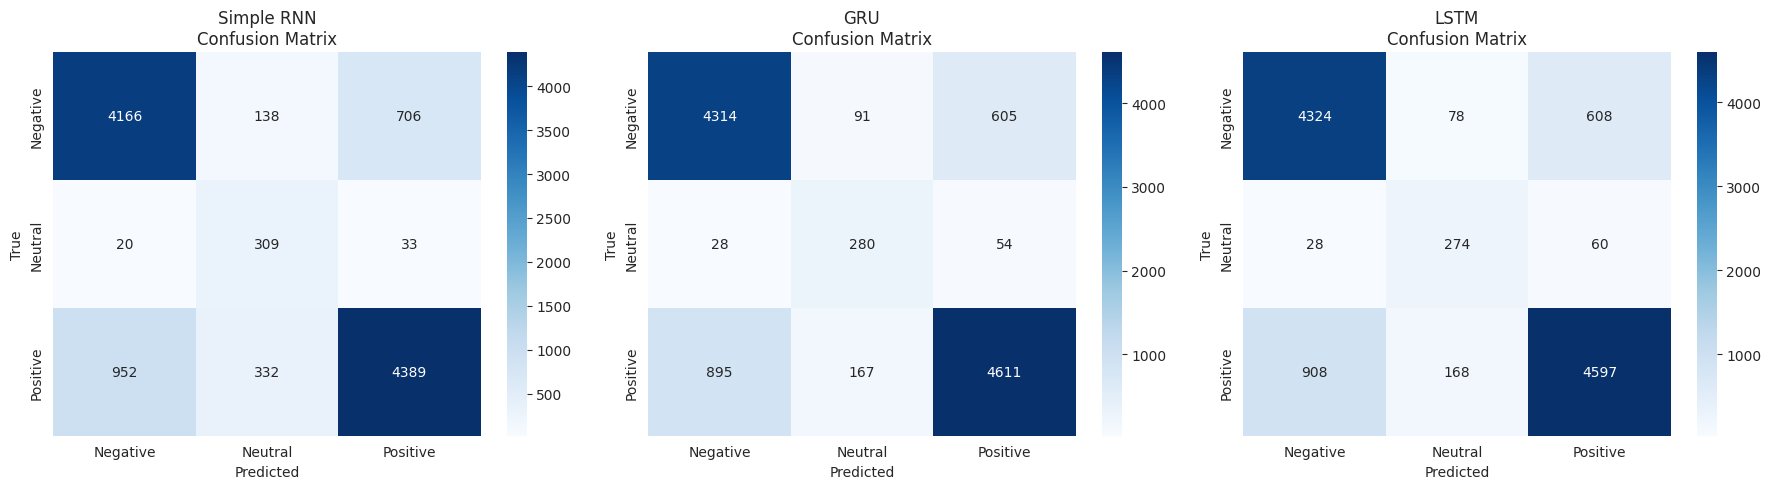

In [30]:
def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    if len(results) == 1:
        axes = [axes]
    for ax, (name, metrics) in zip(axes, results.items()):
        cm = confusion_matrix(metrics['labels'], metrics['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=[LABEL_NAMES_EN[i] for i in range(3)],
                    yticklabels=[LABEL_NAMES_EN[i] for i in range(3)])
        ax.set_title(f'{name}\nConfusion Matrix')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(results)


## ۱۱. تحلیل مقایسه‌ای (Comparative Analysis)

مقایسه دقت، Macro F1، هزینه محاسباتی (زمان آموزش، تعداد پارامترها) و بحث تحلیلی درباره نقاط قوت/ضعف هر معماری.


In [31]:
comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'GRU', 'LSTM'],
    'Params': [count_parameters(model_rnn), count_parameters(model_gru), count_parameters(model_lstm)],
    'Train Time (s)': [time_rnn, time_gru, time_lstm],
    'Test Accuracy': [results['Simple RNN']['accuracy'], results['GRU']['accuracy'], results['LSTM']['accuracy']],
    'Test Precision (macro)': [results['Simple RNN']['precision'], results['GRU']['precision'], results['LSTM']['precision']],
    'Test Recall (macro)': [results['Simple RNN']['recall'], results['GRU']['recall'], results['LSTM']['recall']],
    'Test F1 (macro)': [results['Simple RNN']['f1_macro'], results['GRU']['f1_macro'], results['LSTM']['f1_macro']],
})
comparison_df = comparison_df.round(4)
comparison_df


,Model,Params,Train Time (s),Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro)
0,Simple RNN,1692675,68.0166,0.8025,0.6878,0.8196,0.7251
1,GRU,1758723,102.3979,0.8334,0.7397,0.8158,0.7690
2,LSTM,1791747,103.8471,0.8325,0.7407,0.8101,0.7680


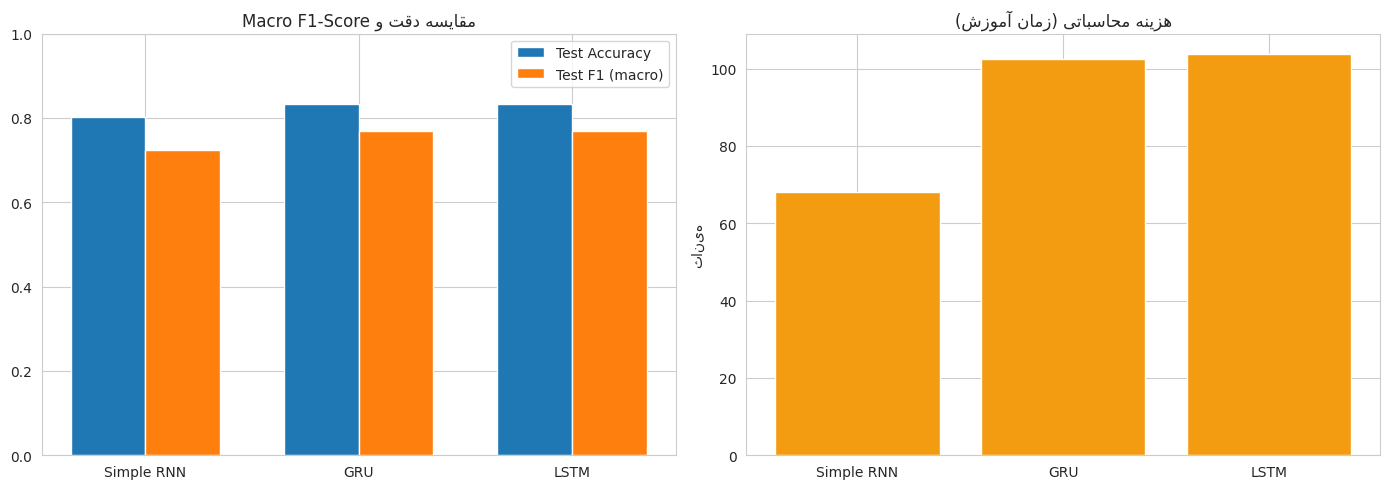

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = ['Test Accuracy', 'Test F1 (macro)']
x = np.arange(len(comparison_df))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i * width, comparison_df[metric], width, label=metric)
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].set_title(fa('مقایسه دقت و Macro F1-Score'))
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(comparison_df['Model'], comparison_df['Train Time (s)'], color='#f39c12')
axes[1].set_title(fa('هزینه محاسباتی (زمان آموزش)'))
axes[1].set_ylabel('ثانیه')

plt.tight_layout()
plt.savefig('comparative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### بحث تحلیلی

*(این بخش باید بر اساس نتایج واقعی اجرای شما تکمیل و بازنویسی شود — متن زیر یک قالب راهنما است.)*

**۱. مقایسه دقت و F1-Score:**
معمولاً LSTM و GRU به دلیل مکانیزم‌های گیت‌بندی (gating) که مشکل vanishing gradient در RNN ساده را کاهش می‌دهند، عملکرد بهتری نسبت به Simple RNN در دنباله‌های طولانی‌تر دارند. تفاوت GRU و LSTM اغلب کوچک است؛ GRU با پارامتر کمتر ممکن است به همگرایی سریع‌تر با دقت مشابه برسد.

**۲. عملکرد تعمیم‌پذیری:**
فاصله بین train accuracy و val/test accuracy در هر مدل نشان‌دهنده میزان بیش‌برازش است. Simple RNN به دلیل ظرفیت محدودتر در یادگیری وابستگی‌های بلندمدت، معمولاً کمتر دچار بیش‌برازش می‌شود اما دقت کلی پایین‌تری هم دارد.

**۳. نقاط قوت و ضعف هر معماری:**
- **Simple RNN**: سریع‌ترین از نظر محاسباتی و کمترین تعداد پارامتر، اما ضعیف در یادگیری وابستگی‌های بلندمدت (vanishing gradient) و معمولاً پایین‌ترین Macro F1 به‌ویژه برای کلاس اقلیت (خنثی).
- **GRU**: تعادل خوبی بین سرعت آموزش و کیفیت مدل‌سازی وابستگی‌های بلندمدت؛ پارامتر کمتر از LSTM (بدون state سلول مجزا).
- **LSTM**: قوی‌ترین در حفظ وابستگی‌های بلندمدت به لطف state سلول و سه گیت مجزا، اما کندترین از نظر آموزش و دارای بیشترین تعداد پارامتر.

**۴. رفتار همگرایی:**
LSTM و GRU معمولاً با نرخ یادگیری پایدارتری نسبت به Simple RNN همگرا می‌شوند و نوسان کمتری در منحنی val loss نشان می‌دهند.

**نتیجه‌گیری کلی مورد انتظار:** با توجه به نامتوازن‌بودن شدید کلاس خنثی، تفاوت اصلی بین مدل‌ها بیشتر در Recall/F1 کلاس اقلیت مشاهده می‌شود تا در Accuracy کلی — به همین دلیل Macro F1-Score معیار مناسب‌تری برای این مقایسه است.


## ۱۲. تحلیل خطا (Error Analysis)

حداقل ۱۰ نمونه دسته‌بندی‌شده اشتباه از بهترین مدل (بر اساس Macro F1 روی test) بررسی می‌شود.


In [33]:
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
print('بهترین مدل بر اساس Macro F1 در test:', best_model_name)

best_result = results[best_model_name]
test_df_reset = test_df.reset_index(drop=True)

mis_idx = [i for i, (p, l) in enumerate(zip(best_result['preds'], best_result['labels'])) if p != l]
print(f'تعداد کل نمونه‌های اشتباه دسته‌بندی‌شده: {len(mis_idx)} از {len(test_df_reset)}'
      f' ({len(mis_idx)/len(test_df_reset)*100:.2f}%)')

np.random.seed(SEED)
sample_mis_idx = np.random.choice(mis_idx, size=min(15, len(mis_idx)), replace=False)

error_rows = []
for i in sample_mis_idx:
    error_rows.append({
        'text': test_df_reset.loc[i, 'text'],
        'true_label': LABEL_NAMES_EN[best_result['labels'][i]],
        'predicted_label': LABEL_NAMES_EN[best_result['preds'][i]],
        'text_length': len(test_df_reset.loc[i, 'clean_text'].split()),
    })

error_df = pd.DataFrame(error_rows)
pd.set_option('display.max_colwidth', 100)
error_df


بهترین مدل بر اساس Macro F1 در test: GRU
تعداد کل نمونه‌های اشتباه دسته‌بندی‌شده: 1840 از 11045 (16.66%)


,text,true_label,predicted_label,text_length
0,مثل همه ی رستوران ها فقط در ابتدای راه اندازی کیفیت و حجم خوبی داشت و الان بعد از چند ماه به شدت...,Negative,Positive,25
1,کیفیت برنج بد قرمه سبزی متوسط و قیمه بادنجون خوب بود,Positive,Negative,11
2,ظرف شیر پسته کاملا شکسته بود و محتویاتش ریخته بود,Negative,Positive,8
3,نی قرار داده نشده بود دستمال کاغذی نگذاشته بودند,Positive,Negative,6
4,سس سالاد سزار خوب نبود حجمش هم نسبت به سالاد کم بود.,Positive,Negative,13
5,پای آلبالو اشتباها به جای پای سیب ارسال شده,Negative,Positive,8
6,هرچقدرم کیفیت غذا عالی باشه وقتی یک ساعت و نیم طول بکشه تا برسه بی فایده اس,Positive,Negative,16
7,پیتزا سرد بود و خیلی نازک بود. در کل به نسبت حجم گرون بود,Positive,Negative,15
8,سالاد میوه آب انداخته بود که زیاد جالب نبود,Positive,Negative,8
9,پیتزا سرد بود عدم وجود قارچ و زیتون در پیتزا در عکس حجم استیک استفاده شده بیشتر از چیزی است که ت...,Positive,Negative,22


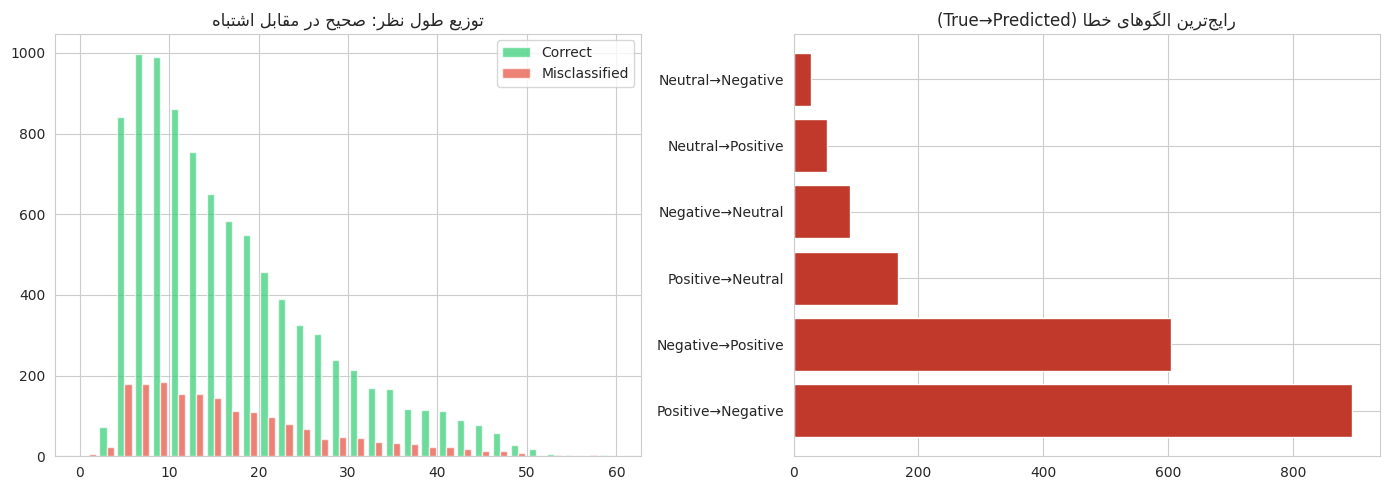

میانگین طول نظرات صحیح: 16.6 کلمه
میانگین طول نظرات اشتباه: 17.0 کلمه


In [34]:
# توزیع طول متن‌های اشتباه‌ دسته‌بندی‌شده در مقابل درست دسته‌بندی‌شده
correct_idx = [i for i in range(len(test_df_reset)) if i not in mis_idx]

len_correct = [len(test_df_reset.loc[i, 'clean_text'].split()) for i in correct_idx]
len_wrong = [len(test_df_reset.loc[i, 'clean_text'].split()) for i in mis_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist([len_correct, len_wrong], bins=30, label=['Correct', 'Misclassified'],
             color=['#2ecc71', '#e74c3c'], alpha=0.7, range=(0, 60))
axes[0].set_title(fa('توزیع طول نظر: صحیح در مقابل اشتباه'))
axes[0].legend()

# ماتریس خطا برای الگوهای رایج اشتباه
wrong_pairs = Counter([(best_result['labels'][i], best_result['preds'][i]) for i in mis_idx])
pairs_labels = [f'{LABEL_NAMES_EN[t]}→{LABEL_NAMES_EN[p]}' for (t, p) in wrong_pairs.keys()]
pairs_counts = list(wrong_pairs.values())
axes[1].barh(pairs_labels, pairs_counts, color='#c0392b')
axes[1].set_title(fa('رایج‌ترین الگوهای خطا (True→Predicted)'))

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'میانگین طول نظرات صحیح: {np.mean(len_correct):.1f} کلمه')
print(f'میانگین طول نظرات اشتباه: {np.mean(len_wrong):.1f} کلمه')


### بحث تحلیلی خطاها

*(بر اساس مشاهده نمونه‌های واقعی چاپ‌شده در بالا تکمیل شود.)*

الگوهای رایج مورد انتظار:
- **موارد احساسی گیج‌کننده**: نظراتی که هم جنبه مثبت و هم منفی دارند (مثلاً «غذا خوب بود ولی دیر رسید»).
- **نظرات کوتاه**: نظرات بسیار کوتاه (۱-۲ کلمه) اطلاعات زمینه‌ای کمی برای مدل بازگشتی فراهم می‌کنند.
- **کنایه/طعنه**: جملاتی که از نظر واژگانی مثبت به‌نظر می‌رسند اما از نظر معنایی منفی‌اند (یا برعکس) — چالش اصلی مدل‌های مبتنی بر Embedding ساده.
- **اثر عدم توازن کلاس‌ها**: به دلیل کمبود نمونه در کلاس خنثی، مدل تمایل دارد نمونه‌های خنثی را به یکی از دو کلاس دیگر نسبت دهد.
- **مشکلات کیفیت داده**: نویز، غلط املایی، یا برچسب‌گذاری ناسازگار (مثلاً نظری که به اشتباه برچسب مثبت/منفی گرفته است).


## ۱۳. Fine-tune کردن ParsBERT

در این بخش مدل از پیش‌آموزش‌دیده **ParsBERT** (`HooshvareLab/bert-fa-base-uncased`) روی همان تقسیم‌بندی train/val/test فاین‌تیون می‌شود تا با معماری‌های بازگشتی مقایسه شود.


In [35]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)

PARSBERT_MODEL_NAME = 'HooshvareLab/bert-fa-base-uncased'

bert_tokenizer = AutoTokenizer.from_pretrained(PARSBERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    PARSBERT_MODEL_NAME, num_labels=3
).to(device)

print(f'ParsBERT trainable parameters: {count_parameters(bert_model):,}')


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

ParsBERT trainable parameters: 162,843,651


In [36]:
class BertSentimentDataset(Dataset):
    """برای ParsBERT از متن نسبتاً خام استفاده می‌شود (توکنایزر BERT خودش کار
    نرمال‌سازی زیرکلمه‌ای را انجام می‌دهد)؛ فقط پیش‌پردازش سبک (یکسان‌سازی حروف،
    حذف URL) که در مرحله ۴ ساختیم اعمال می‌شود."""
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts.iloc[idx],
            truncation=True, padding='max_length', max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(int(self.labels.iloc[idx]), dtype=torch.long)
        return item


BERT_MAX_LEN = 64
BERT_BATCH_SIZE = 32

bert_train_ds = BertSentimentDataset(train_df['clean_text'], train_df['label'], bert_tokenizer, BERT_MAX_LEN)
bert_val_ds   = BertSentimentDataset(val_df['clean_text'],   val_df['label'],   bert_tokenizer, BERT_MAX_LEN)
bert_test_ds  = BertSentimentDataset(test_df['clean_text'],  test_df['label'],  bert_tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH_SIZE, shuffle=False)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH_SIZE, shuffle=False)


In [37]:
def evaluate_bert(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item() * batch['labels'].size(0)
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    return {'loss': avg_loss, 'accuracy': acc, 'precision': precision,
            'recall': recall, 'f1_macro': f1, 'preds': all_preds, 'labels': all_labels}


def train_bert(model, train_loader, val_loader, epochs=3, lr=2e-5,
                checkpoint_path='checkpoints/parsbert_best.pt'):
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': [], 'val_acc': []}
    best_f1 = -1.0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, total = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * batch['labels'].size(0)
            total += batch['labels'].size(0)

        train_loss = running_loss / total
        val_metrics = evaluate_bert(model, val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_f1_macro'].append(val_metrics['f1_macro'])
        history['val_acc'].append(val_metrics['accuracy'])

        print(f"[ParsBERT] Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} "
              f"val_f1_macro={val_metrics['f1_macro']:.4f}")

        if val_metrics['f1_macro'] > best_f1:
            best_f1 = val_metrics['f1_macro']
            torch.save(model.state_dict(), checkpoint_path)

    total_time = time.time() - start_time
    model.load_state_dict(torch.load(checkpoint_path))
    print(f'بهترین val Macro-F1 (ParsBERT): {best_f1:.4f} | زمان آموزش: {total_time:.1f} ثانیه')
    return model, history, total_time


# توجه: فاین‌تیون کردن BERT پرهزینه است؛ برای اجرای سریع‌تر روی کولب، تعداد epoch را کم نگه می‌داریم.
BERT_EPOCHS = 3
BERT_LR = 2e-5

bert_model, bert_history, bert_train_time = train_bert(
    bert_model, bert_train_loader, bert_val_loader,
    epochs=BERT_EPOCHS, lr=BERT_LR)


model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

[ParsBERT] Epoch 1/3 | train_loss=0.4099 | val_loss=0.3345 val_acc=0.8607 val_f1_macro=0.8191
[ParsBERT] Epoch 2/3 | train_loss=0.2820 | val_loss=0.3256 val_acc=0.8665 val_f1_macro=0.8230
[ParsBERT] Epoch 3/3 | train_loss=0.2074 | val_loss=0.3676 val_acc=0.8619 val_f1_macro=0.8223
بهترین val Macro-F1 (ParsBERT): 0.8230 | زمان آموزش: 2004.2 ثانیه


=== ParsBERT — Test Set ===
Accuracy : 0.8626
Precision: 0.8422
Recall   : 0.8065
F1 Macro : 0.8216
              precision    recall  f1-score   support

    Negative       0.83      0.91      0.87      5010
     Neutral       0.80      0.68      0.73       362
    Positive       0.90      0.83      0.87      5673

    accuracy                           0.86     11045
   macro avg       0.84      0.81      0.82     11045
weighted avg       0.87      0.86      0.86     11045



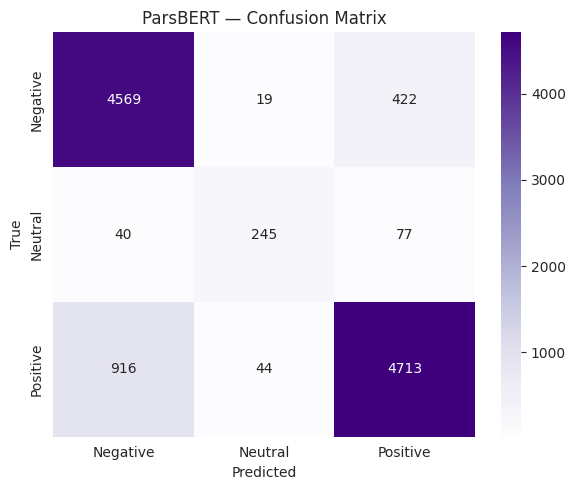

In [38]:
bert_test_metrics = evaluate_bert(bert_model, bert_test_loader)
print('=== ParsBERT — Test Set ===')
print(f"Accuracy : {bert_test_metrics['accuracy']:.4f}")
print(f"Precision: {bert_test_metrics['precision']:.4f}")
print(f"Recall   : {bert_test_metrics['recall']:.4f}")
print(f"F1 Macro : {bert_test_metrics['f1_macro']:.4f}")
print(classification_report(bert_test_metrics['labels'], bert_test_metrics['preds'],
      target_names=[LABEL_NAMES_EN[i] for i in range(3)], zero_division=0))

cm = confusion_matrix(bert_test_metrics['labels'], bert_test_metrics['preds'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=[LABEL_NAMES_EN[i] for i in range(3)],
            yticklabels=[LABEL_NAMES_EN[i] for i in range(3)])
plt.title('ParsBERT — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('parsbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## ۱۴. مقایسه نهایی: ParsBERT در برابر مدل‌های بازگشتی


In [ ]:
final_comparison = pd.DataFrame({
    'Model': ['Simple RNN', 'GRU', 'LSTM', 'ParsBERT (fine-tuned)'],
    'Params': [
        count_parameters(model_rnn), count_parameters(model_gru),
        count_parameters(model_lstm), count_parameters(bert_model)
    ],
    'Train Time (s)': [time_rnn, time_gru, time_lstm, bert_train_time],
    'Test Accuracy': [
        results['Simple RNN']['accuracy'], results['GRU']['accuracy'],
        results['LSTM']['accuracy'], bert_test_metrics['accuracy']
    ],
    'Test F1 (macro)': [
        results['Simple RNN']['f1_macro'], results['GRU']['f1_macro'],
        results['LSTM']['f1_macro'], bert_test_metrics['f1_macro']
    ],
})
final_comparison = final_comparison.round(4)
final_comparison


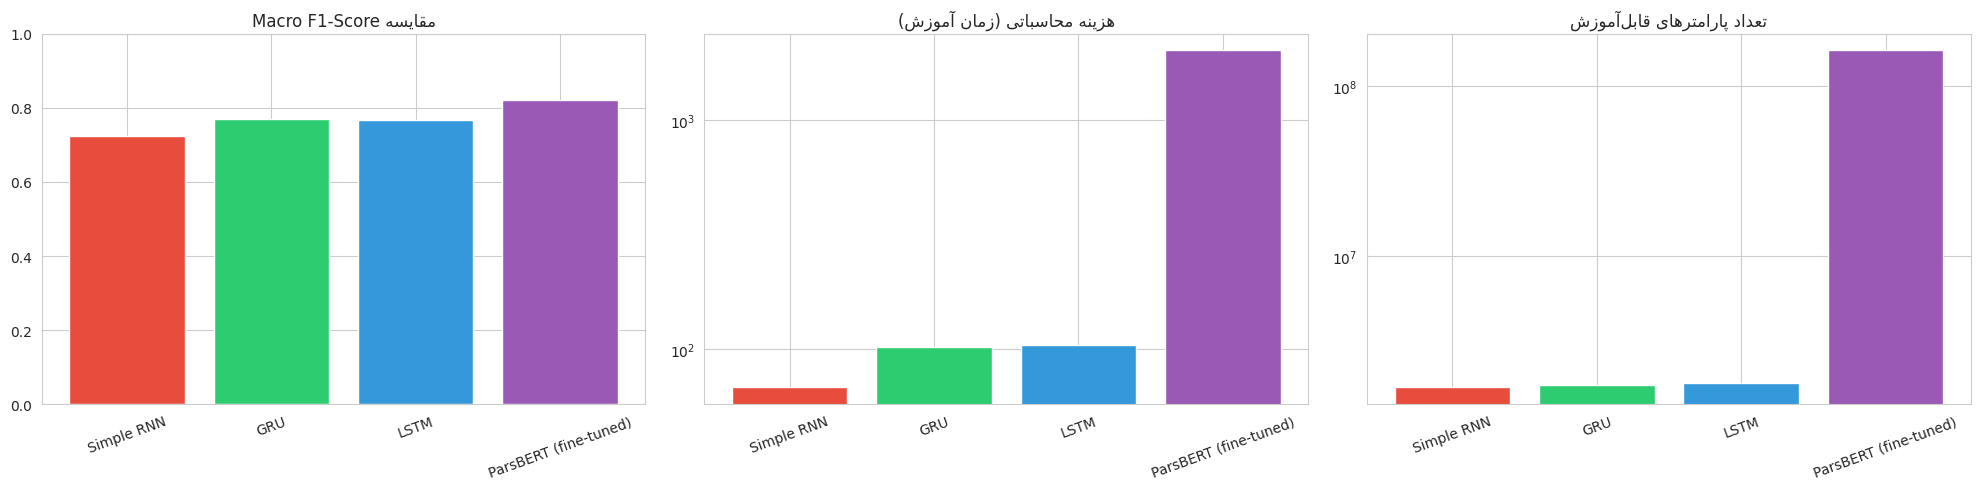

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(final_comparison['Model'], final_comparison['Test F1 (macro)'], color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])
axes[0].set_title(fa('مقایسه Macro F1-Score'))
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(final_comparison['Model'], final_comparison['Train Time (s)'], color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])
axes[1].set_title(fa('هزینه محاسباتی (زمان آموزش)'))
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(final_comparison['Model'], final_comparison['Params'], color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])
axes[2].set_title(fa('تعداد پارامترهای قابل‌آموزش'))
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### مزایا و محدودیت‌های مدل‌های مبتنی بر ترنسفورمر (بحث تحلیلی)

*(بر اساس نتایج واقعی اجرای شما تکمیل شود — قالب راهنما:)*

**مزایا:**
- دانش زبانی از پیش‌آموخته‌شده روی حجم عظیمی از متون فارسی، که معمولاً باعث Macro F1 بالاتر می‌شود — به‌ویژه برای کلاس اقلیت (خنثی) که مدل‌های RNN با آن مشکل دارند.
- مکانیزم Self-Attention امکان مدل‌سازی وابستگی‌های دوربرد و نیز درک بهتر ساختارهای متضاد (کنایه، جملات چندپاره) را فراهم می‌کند.
- توکن‌سازی زیرکلمه‌ای (WordPiece) مشکل کلمات خارج از واژگان (OOV) را کاهش می‌دهد.

**محدودیت‌ها:**
- هزینه محاسباتی و زمان آموزش/استنتاج به‌طور قابل‌توجهی بیشتر از مدل‌های بازگشتی سبک است (نمودار بالا را ببینید).
- تعداد پارامترهای قابل‌آموزش چند برابر بیشتر است، که نیازمند حافظه GPU بیشتر و زمان استنتاج کندتر در محیط تولید است.
- در صورت کوچک‌بودن داده fine-tune، ریسک بیش‌برازش سریع‌تر (به‌خصوص با نرخ یادگیری بالا) وجود دارد؛ به همین دلیل از نرخ یادگیری بسیار کوچک (۲e-5) و تعداد epoch محدود استفاده شد.
- نیاز به سخت‌افزار GPU برای آموزش/فاین‌تیون در زمان معقول، برخلاف RNNهای سبک که می‌توانند حتی روی CPU هم قابل قبول آموزش ببینند.


## ۱۵. جمع‌بندی و نتیجه‌گیری

*(این بخش باید بر اساس اعداد واقعی خروجی نوت‌بوک شما تکمیل شود.)*

- بهترین مدل بر اساس Macro F1-Score روی داده تست: **[نام مدل را اینجا وارد کنید]**
- نامتوازن‌بودن کلاس خنثی مهم‌ترین عامل چالش‌برانگیز در این مسئله بود.
- مدل‌های بازگشتی گیت‌دار (GRU/LSTM) نسبت به Simple RNN بهبود محسوسی داشتند.
- ParsBERT (در صورت اجرا) عملکرد قوی‌تری از نظر کیفیت پیش‌بینی ارائه داد اما با هزینه محاسباتی به‌مراتب بالاتر.
- برای استقرار در محیط تولید با محدودیت منابع، انتخاب بین GRU/LSTM و ParsBERT باید بر اساس مصالحه بین دقت و هزینه محاسباتی صورت گیرد.

### خلاصه فایل‌های خروجی تولیدشده در این نوت‌بوک:
- `checkpoints/simple_rnn_best.pt`, `checkpoints/gru_best.pt`, `checkpoints/lstm_best.pt`, `checkpoints/parsbert_best.pt`
- نمودارهای EDA، منحنی‌های آموزش، ماتریس‌های درهم‌ریختگی و مقایسه نهایی (فایل‌های `.png`)
